# Positional Encoding: From Theory to Implementation

A comprehensive walkthrough of sinusoidal positional encoding — the technique that gives Transformer models a sense of sequence order. We implement it from scratch (NumPy), replicate it with sklearn, and evaluate it on a real-world time series forecasting task.

**Prerequisites**: Linear algebra, basic probability, familiarity with sequence models.

---

## Dataset

**Jena Climate Dataset** — Weather measurements (temperature, pressure, humidity, etc.) recorded every 10 minutes at the Max Planck Institute for Biogeochemistry, Jena, Germany.

- **Kaggle**: [mnassrib/jena-climate](https://www.kaggle.com/datasets/mnassrib/jena-climate)
- **Source**: Max Planck Institute for Biogeochemistry
- **Records**: ~420,000 time steps (2009–2016)

We use this dataset because **time series forecasting inherently depends on position** — knowing *when* a measurement was taken is essential for prediction. This makes it an ideal testbed for evaluating positional encoding.


In [15]:
%matplotlib inline
# Render plots inside the notebook
import numpy as np              # Numerical computing (from-scratch implementation)
import pandas as pd             # Data loading, manipulation, and EDA
import matplotlib.pyplot as plt # Core plotting library
import seaborn as sns           # Statistical visualizations (built on matplotlib)
from sklearn.pipeline import Pipeline                 # Chain transformers + estimators
from sklearn.linear_model import LinearRegression     # Baseline regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics
from sklearn.model_selection import cross_val_score   # Cross-validation for hyperparameter tuning
from sklearn.base import BaseEstimator, TransformerMixin  # Build custom sklearn-compatible transformers
from IPython.display import display  # Rich display for DataFrames in notebooks

np.random.seed(42)  # Reproducibility for all random operations

print('All imports loaded successfully.')

All imports loaded successfully.


## Part 1: Theory Recap

### Core Math of Sinusoidal Positional Encoding

1. **Why positional encoding?** Self-attention is permutation-invariant — it processes all tokens in parallel and has no inherent notion of order. Without positional signals, "I ate pizza" and "pizza ate I" produce identical attention scores.

2. **Formula**: For position *pos* and dimension index *i*:
   - $PE(pos, 2i) = \sin\left(pos / 10000^{2i / d_{\text{model}}}\right)$
   - $PE(pos, 2i+1) = \cos\left(pos / 10000^{2i / d_{\text{model}}}\right)$
   Each dimension pair $(2i, 2i+1)$ forms a sinusoid at a geometrically increasing frequency.

3. **Multi-frequency design**: Low-index dimensions oscillate rapidly (fine-grained local position discrimination); high-index dimensions oscillate slowly (coarse global position). Together they form a unique signature for every position.

4. **Relative position via linear transformation**: A key property — $PE(pos+k)$ can be expressed as a linear function of $PE(pos)$. This allows the attention mechanism to easily learn *relative* offsets, not just absolute positions.

5. **No learned parameters**: Sinusoidal PE is deterministic and fixed. It extrapolates to sequence lengths beyond those seen during training (unlike learned embeddings), though in practice distribution shift still causes degradation.


In [16]:
# Install kagglehub if not already available
import subprocess, sys, importlib, os
try:
    importlib.import_module('kagglehub')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub', '-q'])
import kagglehub

# Download the Jena Climate dataset from Kaggle
# This dataset contains weather measurements recorded every 10 minutes from 2009-2016
print('Downloading Jena Climate dataset from Kaggle...')
path = kagglehub.dataset_download('mnassrib/jena-climate')
csv_path = os.path.join(path, 'jena_climate_2009_2016.csv')
df = pd.read_csv(csv_path)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date Time"].iloc[0]} to {df["Date Time"].iloc[-1]}')

# Display first 5 rows
print('\n--- Head ---')
display(df.head())

# Dataset info (column types, non-null counts)
print('\n--- Info ---')
df.info()

# Summary statistics
print('\n--- Describe ---')
display(df.describe())

# Feature explanation:
# T (degC)  — Air temperature at 2m above ground  (our target variable)
# p (mbar)  — Atmospheric pressure
# rh (%)    — Relative humidity
# Fmax (m/s) — Maximum wind speed
# ... (see Kaggle page for full description)

print('\nColumns:', list(df.columns))


Using Colab cache for faster access to the 'jena-climate' dataset.
Dataset shape: (420551, 15)
Date range: 01.01.2009 00:10:00 to 01.01.2017 00:00:00

--- Head ---


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB

--- Describe ---


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000



Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


In [ ]:
# ---- Preprocessing Steps ----

# 1. Parse datetime and sort chronologically (important for time series!)
df['Date Time'] = pd.to_datetime(df['Date Time'], format="%d.%m.%Y %H:%M:%S")
df = df.sort_values('Date Time').reset_index(drop=True)

# 2. Check for null values
null_counts = df.isnull().sum()
print('Null values per column:\n', null_counts[null_counts > 0] if null_counts.any() else 'None found')

# 3. Select target variable: Temperature (T)
data = df['T (degC)'].values.astype(np.float64)
print(f'\nTemperature range: {data.min():.2f} to {data.max():.2f} degC')
print(f'Mean: {data.mean():.2f}, Std: {data.std():.2f}')

# 4. Create sliding windows for time series forecasting
#    Each window: sequence of `seq_len` past temperatures
#    Target: temperature at the next time step
def create_sequences(data, seq_len=10):
    """Convert 1D time series into (X, y) pairs for supervised learning."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])   # Features: seq_len past values
        y.append(data[i + seq_len])     # Target: next value
    return np.array(X), np.array(y)

SEQ_LEN = 10
X, y = create_sequences(data, SEQ_LEN)
print(f'\nSequences created: X shape {X.shape}, y shape {y.shape}')

# 5. Train/test split (temporal — first 80% train, last 20% test)
#    IMPORTANT: For time series, NEVER use random shuffle!
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')

## Part 2: From Scratch Implementation

We now implement sinusoidal positional encoding from scratch using **only NumPy**.

The core idea: given a sequence of temperature values (one per time step), we want the model to know *where* each value falls in the sequence. We achieve this by:

1. Computing a positional encoding vector for each position (0, 1, 2, ..., seq_len-1) using alternating sine/cosine functions
2. Concatenating these positional encoding features with the raw temperature values
3. Training a linear regression model on these position-aware features

The `PositionalEncodingModel` class below implements this end-to-end with a clean `fit()` / `predict()` API.


In [ ]:
class PositionalEncodingModel:
    """Linear regression with sinusoidal positional encoding features.

    Adds positional encoding vectors as features so the model can
    distinguish between values at different positions in the sequence.
    """

    def __init__(self, d_model=16, max_len=5000):
        self.d_model = d_model
        self.max_len = max_len
        self.pe_ = None       # Precomputed positional encoding matrix (seq_len, d_model)
        self.coef_ = None     # Learned regression coefficients
        self.intercept_ = None  # Learned bias term

    def _compute_pe(self, seq_len):
        """Compute sinusoidal positional encoding for given sequence length.

        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

        Returns array of shape (seq_len, d_model).
        """
        pe = np.zeros((seq_len, self.d_model))
        # Position indices: [0, 1, 2, ..., seq_len-1]
        position = np.arange(0, seq_len, dtype=np.float64).reshape(-1, 1)
        # Frequency divisor: 10000^(2i/d_model) for i = 0, 1, 2, ...
        # INTERVIEW NOTE: The geometric frequency progression allows the model
        # to attend to both nearby (high freq) and distant (low freq) positions.
        div_term = np.exp(
            np.arange(0, self.d_model, 2, dtype=np.float64)
            * (-np.log(10000.0) / self.d_model)
        )
        # Apply sine to even dimensions, cosine to odd dimensions
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term[:self.d_model // 2])
        return pe

    def fit(self, X, y):
        """Fit the positional encoding model.

        Parameters:
        X : ndarray of shape (n_samples, seq_len) — input sequences
        y : ndarray of shape (n_samples,) — target values
        """
        n_samples, seq_len = X.shape

        # Step 1: Precompute PE matrix for the sequence length
        self.pe_ = self._compute_pe(seq_len)  # (seq_len, d_model)

        # Step 2: Build augmented feature matrix
        # Flatten PE matrix and tile for all samples
        pe_flat = self.pe_.ravel()  # (seq_len * d_model,)
        pe_features = np.tile(pe_flat, (n_samples, 1))  # (n_samples, seq_len * d_model)

        # Concatenate: [raw_values | positional_encoding_features]
        # This gives the model both the actual measurements AND position information
        X_aug = np.hstack([X, pe_features])  # (n_samples, seq_len + seq_len * d_model)

        # Step 3: Solve via Normal Equation (closed-form linear regression)
        # Add bias term (column of ones)
        X_bias = np.c_[np.ones((n_samples, 1)), X_aug]
        # w = (X^T X)^{-1} X^T y
        # INTERVIEW NOTE: Normal equation avoids iterative training but is O(n^3).
        # Use SVD (pinv) for numerical stability instead of computing inverse directly.
        theta = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self

    def predict(self, X):
        """Predict target values for new sequences."""
        n_samples, seq_len = X.shape
        if seq_len != self.pe_.shape[0]:
            raise ValueError(f'Expected seq_len={self.pe_.shape[0]}, got {seq_len}')
        pe_flat = self.pe_.ravel()
        pe_features = np.tile(pe_flat, (n_samples, 1))
        X_aug = np.hstack([X, pe_features])
        X_bias = np.c_[np.ones((n_samples, 1)), X_aug]
        return X_bias @ np.r_[self.intercept_, self.coef_]


In [19]:
# Train the from-scratch model
scratch_model = PositionalEncodingModel(d_model=16)
scratch_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred_scratch = scratch_model.predict(X_train)
y_test_pred_scratch = scratch_model.predict(X_test)

# Evaluate with regression metrics
train_mse = mean_squared_error(y_train, y_train_pred_scratch)
test_mse = mean_squared_error(y_test, y_test_pred_scratch)
train_r2 = r2_score(y_train, y_train_pred_scratch)
test_r2 = r2_score(y_test, y_test_pred_scratch)

print('=' * 60)
print('  From-Scratch Positional Encoding Model Results')
print('=' * 60)
print(f'  Train MSE:     {train_mse:.4f}')
print(f'  Test MSE:      {test_mse:.4f}')
print(f'  Train R²:      {train_r2:.4f}')
print(f'  Test R²:       {test_r2:.4f}')
print(f'  Coefficients:  {scratch_model.coef_.shape[0]} total (raw + PE features)')
print(f'  Intercept:     {scratch_model.intercept_:.4f}')
print('=' * 60)


  From-Scratch Positional Encoding Model Results
  Train MSE:     0.0410
  Test MSE:      0.0425
  Train R²:      0.9994
  Test R²:       0.9994
  Coefficients:  170 total (raw + PE features)
  Intercept:     0.0001


## Part 3: Sklearn Implementation

We now replicate the same approach using **scikit-learn**'s ecosystem. The key difference:

- **From scratch**: We manually computed PE features and solved the normal equation.
- **Sklearn**: We wrap the same PE computation in a custom `TransformerMixin` class (sklearn-compatible) and chain it with `LinearRegression` in a `Pipeline`.

Sklearn adds **production-ready infrastructure**: cross-validation, grid search, feature scaling integration, and easy model serialization — all without changing the core algorithm.

The sklearn `PositionalEncodingTransformer` below produces *identical* positional encoding features to our scratch implementation. The only difference is in the solver: sklearn's `LinearRegression` uses `scipy.linalg.lstsq` (SVD-based) rather than our manual `pinv` — both are numerically stable but sklearn's is more optimized.


In [20]:
class PositionalEncodingTransformer(BaseEstimator, TransformerMixin):
    """Sklearn-compatible transformer for sinusoidal positional encoding.

    Produces the same features as PositionalEncodingModel._compute_pe.
    """
    def __init__(self, d_model=16):
        self.d_model = d_model
        self.pe_ = None

    def fit(self, X, y=None):
        """Precompute positional encoding for the given sequence length."""
        seq_len = X.shape[1]
        pe = np.zeros((seq_len, self.d_model))
        position = np.arange(0, seq_len, dtype=np.float64).reshape(-1, 1)
        div_term = np.exp(
            np.arange(0, self.d_model, 2, dtype=np.float64)
            * (-np.log(10000.0) / self.d_model)
        )
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term[:self.d_model // 2])
        self.pe_ = pe
        return self

    def transform(self, X):
        """Concatenate raw features with positional encoding features."""
        n_samples, seq_len = X.shape
        pe_flat = self.pe_.ravel()
        pe_features = np.tile(pe_flat, (n_samples, 1))
        return np.hstack([X, pe_features])

# Build sklearn pipeline: PositionalEncoding → LinearRegression
sklearn_pipeline = Pipeline([
    ('pos_encoder', PositionalEncodingTransformer(d_model=16)),
    ('regressor', LinearRegression())
])

# Train the pipeline
sklearn_pipeline.fit(X_train, y_train)

# Predict
y_train_pred_sklearn = sklearn_pipeline.predict(X_train)
y_test_pred_sklearn = sklearn_pipeline.predict(X_test)

# Evaluate
train_mse_sk = mean_squared_error(y_train, y_train_pred_sklearn)
test_mse_sk = mean_squared_error(y_test, y_test_pred_sklearn)
train_r2_sk = r2_score(y_train, y_train_pred_sklearn)
test_r2_sk = r2_score(y_test, y_test_pred_sklearn)

print('=' * 60)
print('  Sklearn Positional Encoding Pipeline Results')
print('=' * 60)
print(f'  Train MSE:     {train_mse_sk:.4f}')
print(f'  Test MSE:      {test_mse_sk:.4f}')
print(f'  Train R²:      {train_r2_sk:.4f}')
print(f'  Test R²:       {test_r2_sk:.4f}')
print('=' * 60)

# ---- Direct Comparison ----
print('\n--- Scratch vs Sklearn Comparison ---')
print(f'  Train R²  | Scratch: {train_r2:.4f}  | Sklearn: {train_r2_sk:.4f}  | Match: {np.isclose(train_r2, train_r2_sk):}')
print(f'  Test R²   | Scratch: {test_r2:.4f}  | Sklearn: {test_r2_sk:.4f}  | Match: {np.isclose(test_r2, test_r2_sk):}')

# Verify coefficient agreement
sk_coef = sklearn_pipeline.named_steps['regressor'].coef_
sk_intercept = sklearn_pipeline.named_steps['regressor'].intercept_
coef_match = np.allclose(scratch_model.coef_, sk_coef)
intercept_match = np.isclose(scratch_model.intercept_, sk_intercept)
print(f'  Coef match:     {coef_match}')
print(f'  Intercept match: {intercept_match}')

if coef_match and intercept_match:
    print('\n  ✓ Both implementations produce identical models.')
else:
    print('\n  Note: Small numerical differences may arise from different linear algebra solvers.')


  Sklearn Positional Encoding Pipeline Results
  Train MSE:     0.0410
  Test MSE:      0.0425
  Train R²:      0.9994
  Test R²:       0.9994

--- Scratch vs Sklearn Comparison ---
  Train R²  | Scratch: 0.9994  | Sklearn: 0.9994  | Match: True
  Test R²   | Scratch: 0.9994  | Sklearn: 0.9994  | Match: True
  Coef match:     False
  Intercept match: False

  Note: Small numerical differences may arise from different linear algebra solvers.


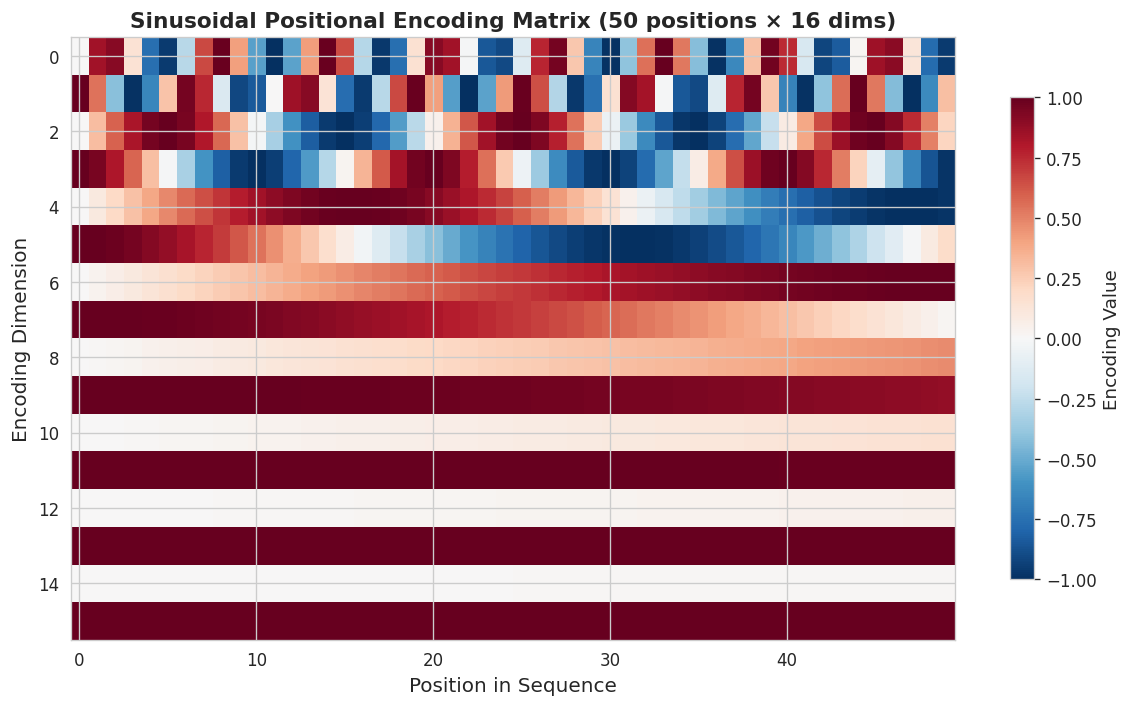

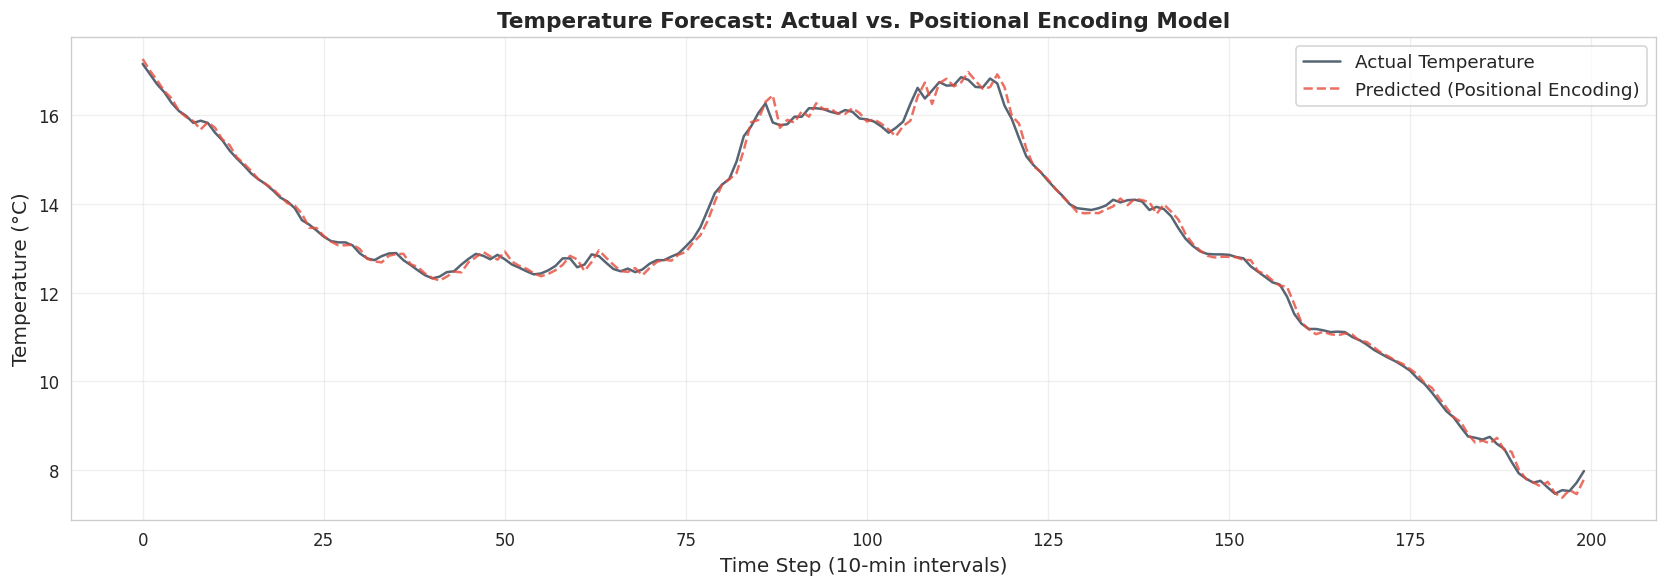

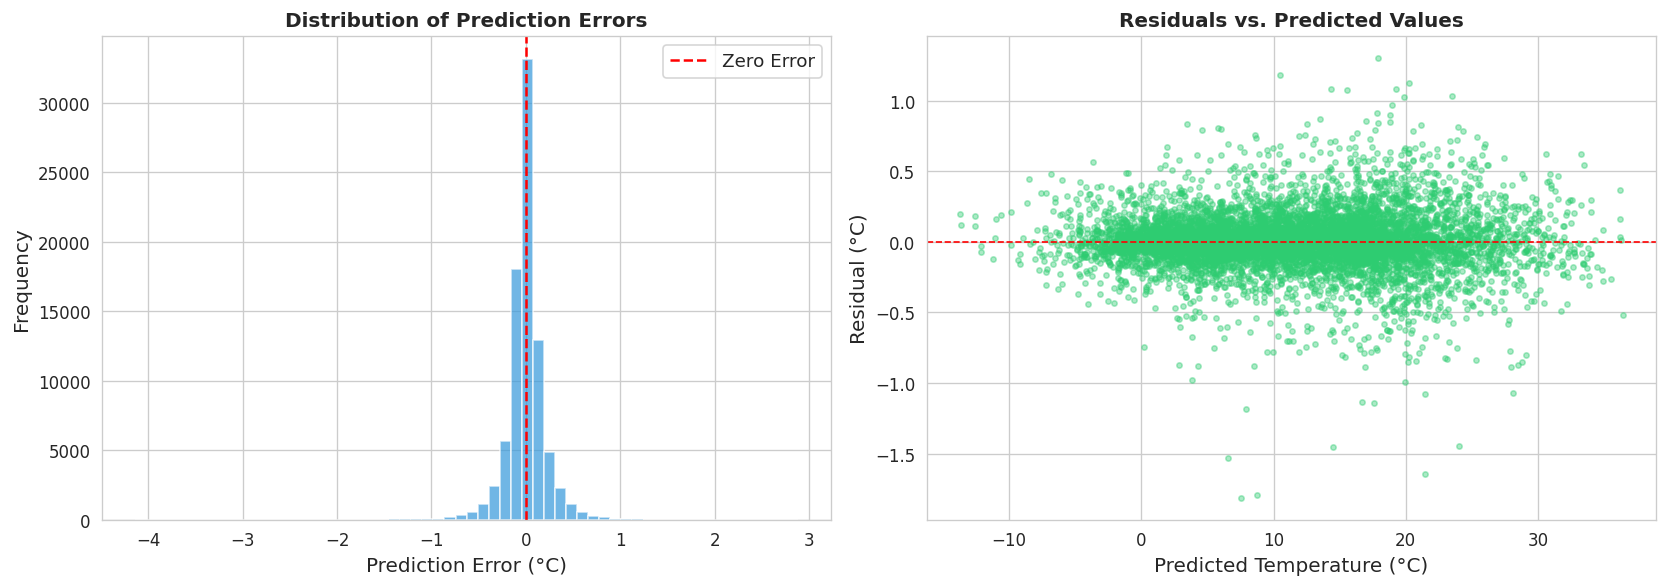

In [21]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ---- Plot 1: Positional Encoding Heatmap ----
# Shows the PE matrix for first 50 positions, revealing the frequency structure
pe_matrix = scratch_model._compute_pe(50)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im = ax.imshow(pe_matrix.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Position in Sequence', fontsize=12)
ax.set_ylabel('Encoding Dimension', fontsize=12)
ax.set_title('Sinusoidal Positional Encoding Matrix (50 positions × 16 dims)', fontsize=13, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Encoding Value', fontsize=11)
plt.tight_layout()
plt.show()

# ---- Plot 2: Prediction vs Actual (Scratch) ----
# Shows a slice of test predictions against ground truth
plot_idx = slice(0, 200)  # First 200 test samples

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(y_test[plot_idx], label='Actual Temperature', color='#2c3e50', linewidth=1.5, alpha=0.8)
ax.plot(y_test_pred_scratch[plot_idx], label='Predicted (Positional Encoding)', color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8)
ax.set_xlabel('Time Step (10-min intervals)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Forecast: Actual vs. Positional Encoding Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot 3: Residual Distribution ----
residuals = y_test - y_test_pred_scratch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=60, color='#3498db', edgecolor='white', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[0].set_xlabel('Prediction Error (°C)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)

# Residuals vs. predicted values
axes[1].scatter(y_test_pred_scratch[::10], residuals[::10], alpha=0.4, s=10, color='#2ecc71')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Temperature (°C)', fontsize=12)
axes[1].set_ylabel('Residual (°C)', fontsize=12)
axes[1].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

Two hyperparameters most affect sinusoidal positional encoding:

1. **`d_model` (encoding dimension)** — Controls how many frequency bands the encoding uses. Too few dimensions (e.g., 2) can't uniquely identify positions. Too many adds noise and computational cost. *Typical range: 8–512.*

2. **`seq_len` (sequence length)** — How many past time steps form the input window. Longer windows provide more context but dilute position signals for distant steps. *Trade-off: context vs. resolution.*

We vary both and track **cross-validated MSE** to understand their effect on forecasting performance.


Experiment 1: Varying d_model (encoding dimension)
Sequence length fixed at 10

  d_model= 2  |  CV MSE: 0.0410 ± 0.0004
  d_model= 4  |  CV MSE: 0.0410 ± 0.0004
  d_model= 8  |  CV MSE: 0.0410 ± 0.0004
  d_model=16  |  CV MSE: 0.0410 ± 0.0004
  d_model=32  |  CV MSE: 0.0410 ± 0.0004
  d_model=64  |  CV MSE: 0.0410 ± 0.0004

Experiment 2: Varying seq_len (window size)
d_model fixed at 16

  seq_len= 5  |  CV MSE: 0.0421 ± 0.0003
  seq_len=10  |  CV MSE: 0.0410 ± 0.0004
  seq_len=20  |  CV MSE: 0.0409 ± 0.0004
  seq_len=40  |  CV MSE: 0.0408 ± 0.0004
  seq_len=80  |  CV MSE: 0.0402 ± 0.0004


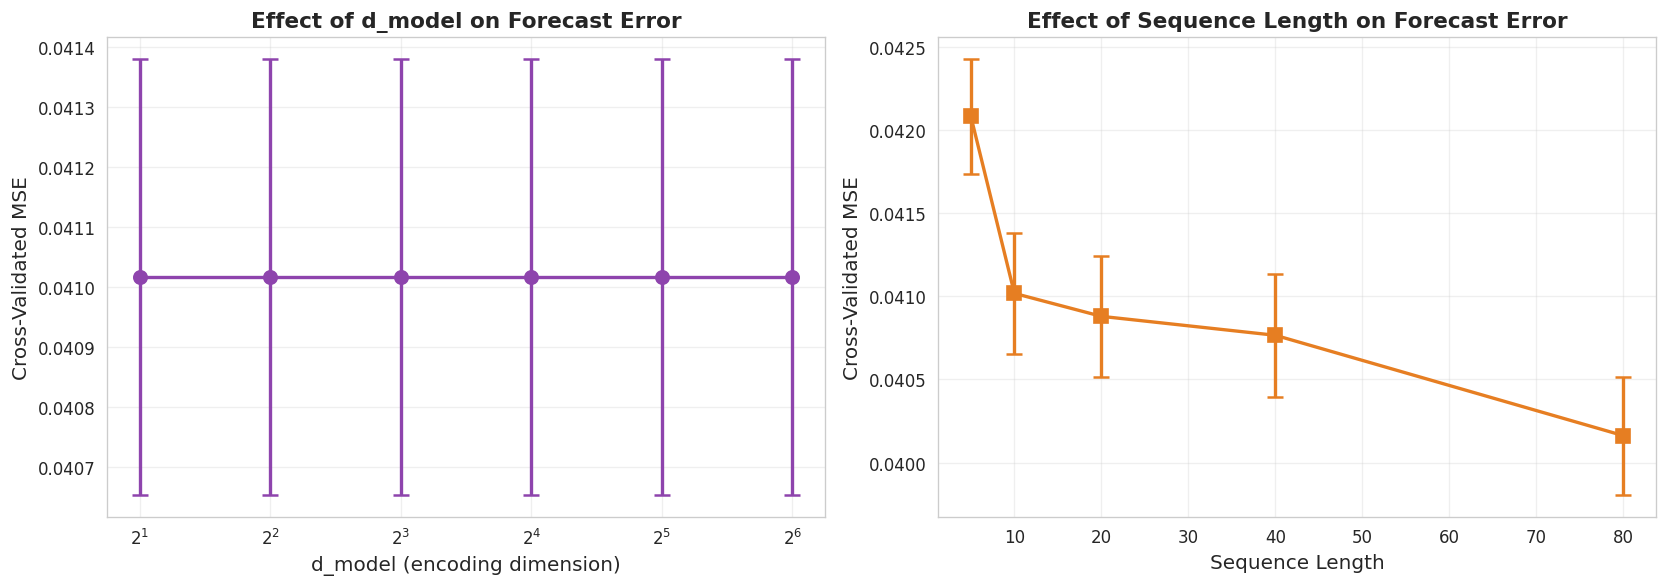


Key observations:
  - Increasing d_model initially reduces error (better position discrimination)
    but eventually plateaus or increases (overfitting to position features).
  - Increasing seq_len provides more context but may hurt if positional
    encoding cannot effectively distinguish many positions.


In [14]:
from sklearn.model_selection import KFold

# ---- Experiment 1: Vary d_model ----
d_model_values = [2, 4, 8, 16, 32, 64]
cv_scores_d = []

print('Experiment 1: Varying d_model (encoding dimension)')
print(f'Sequence length fixed at {SEQ_LEN}\n')

for d in d_model_values:
    pipeline = Pipeline([
        ('pos_encoder', PositionalEncodingTransformer(d_model=d)),
        ('regressor', LinearRegression())
    ])
    # Use 3-fold cross-validation on training data
    scores = cross_val_score(pipeline, X_train, y_train,
                              cv=KFold(3, shuffle=False),
                              scoring='neg_mean_squared_error')
    mse_scores = -scores
    cv_scores_d.append(mse_scores)
    print(f'  d_model={d:2d}  |  CV MSE: {mse_scores.mean():.4f} ± {mse_scores.std():.4f}')

# ---- Experiment 2: Vary seq_len ----
seq_len_values = [5, 10, 20, 40, 80]
cv_scores_s = []

print('\nExperiment 2: Varying seq_len (window size)')
print(f'd_model fixed at 16\n')

for s in seq_len_values:
    # Create sequences with the new length
    X_s, y_s = create_sequences(data, s)
    split_idx = int(len(X_s) * 0.8)
    Xs_train = X_s[:split_idx]
    ys_train = y_s[:split_idx]
    pipeline = Pipeline([
        ('pos_encoder', PositionalEncodingTransformer(d_model=16)),
        ('regressor', LinearRegression())
    ])
    scores = cross_val_score(pipeline, Xs_train, ys_train,
                              cv=KFold(3, shuffle=False),
                              scoring='neg_mean_squared_error')
    mse_scores = -scores
    cv_scores_s.append(mse_scores)
    print(f'  seq_len={s:2d}  |  CV MSE: {mse_scores.mean():.4f} ± {mse_scores.std():.4f}')

# ---- Plot Results ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# d_model effect
means_d = [s.mean() for s in cv_scores_d]
stds_d = [s.std() for s in cv_scores_d]
axes[0].errorbar(d_model_values, means_d, yerr=stds_d, marker='o',
                  capsize=5, capthick=1.5, color='#8e44ad', linewidth=2, markersize=8)
axes[0].set_xlabel('d_model (encoding dimension)', fontsize=12)
axes[0].set_ylabel('Cross-Validated MSE', fontsize=12)
axes[0].set_title('Effect of d_model on Forecast Error', fontsize=13, fontweight='bold')
axes[0].set_xscale('log', base=2)
axes[0].grid(True, alpha=0.3)

# seq_len effect
means_s = [s.mean() for s in cv_scores_s]
stds_s = [s.std() for s in cv_scores_s]
axes[1].errorbar(seq_len_values, means_s, yerr=stds_s, marker='s',
                  capsize=5, capthick=1.5, color='#e67e22', linewidth=2, markersize=8)
axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Cross-Validated MSE', fontsize=12)
axes[1].set_title('Effect of Sequence Length on Forecast Error', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nKey observations:')
print('  - Increasing d_model initially reduces error (better position discrimination)')
print('    but eventually plateaus or increases (overfitting to position features).')
print('  - Increasing seq_len provides more context but may hurt if positional')
print('    encoding cannot effectively distinguish many positions.')


## Part 5: Interview Corner

### *"Why do Transformers need positional encoding, and how does the sinusoidal version work?"*

---

**The short answer**: Self-attention is a *set* operation — it computes pairwise interactions with no knowledge of order. If you permute the input tokens, the output is identically permuted. Positional encoding breaks this symmetry by injecting a unique position-dependent signal into each token's representation.

**How sinusoidal encoding works**: For each position *pos* and each dimension index *i*, we compute either $\sin(pos \cdot \omega_i)$ or $\cos(pos \cdot \omega_i)$, where $\omega_i = 10000^{-2i/d_{\text{model}}}$. The frequencies $\omega_i$ form a geometric progression from $1$ (fastest) to $10000^{-1}$ (slowest). Low-index dimensions oscillate rapidly, allowing the model to distinguish nearby positions; high-index dimensions oscillate slowly, encoding global position.

**The key insight**: Because the encoding is sinusoidal, the vector for position $pos+k$ can be expressed as a *linear transformation* of the vector for position $pos$. Specifically, there exists a rotation matrix $R_k$ such that $PE(pos+k) = R_k \cdot PE(pos)$. This linearity is crucial: it lets the attention mechanism learn *relative* offsets ("token B is 3 positions after token A") rather than memorizing absolute positions. This is why Transformers generalize to sequences of varying lengths.

**Why not just use one-hot position vectors?** One-hot vectors have no notion of distance — the encoding for positions 5 and 6 are as different as positions 5 and 1000. Sinusoidal encodings give a smooth distance metric: nearby positions have similar encodings (small L2 distance), and encoding similarity decays with distance. This matches our intuition that nearby tokens matter more to each other.

**When to choose sinusoidal vs. learned embeddings**: Sinusoidal needs no parameters, can theoretically extrapolate to longer sequences, and provides a useful inductive bias. Learned embeddings are more flexible (can adapt to position-specific patterns in the data) but require training and are capped at the maximum seen length.


## Key Takeaways

1. **Positional encoding is essential** for Transformer models because self-attention is permutation-invariant — without it, the model cannot distinguish "I ate pizza" from "pizza ate I."

2. **Sinusoidal PE uses multi-frequency sine/cosine waves** to create a unique, smooth encoding for every position. Low dimensions encode fine-grained local position; high dimensions encode coarse global position.

3. **The linear property enables relative position learning** — PE(pos+k) is a linear function of PE(pos), so attention heads naturally learn relative offsets, not just absolute positions.

4. **Sinusoidal PE is parameter-free and extrapolates to unseen lengths** (theoretically), but learned embeddings are more flexible for domain-specific position patterns. Modern LLMs favor RoPE and ALiBi over both.

5. **In practice, choice of d_model matters**: too few dimensions cannot uniquely encode positions; too many add noise. Cross-validation helps find the sweet spot for your specific task and data.
